## Incident Clustering - K-Distance Elbow Analysis

This notebook demonstrates the full clustering pipeline from `run_clustering.py`  
using **synthetic data** so you can run it without a Django database.

**Goal:** use the K-Distance (Elbow) graph to find the optimal `DBSCAN_EPS` value.

---
### Pipeline Overview
```
Raw Reports  →  Geo Distance Matrix  →  Cosine Similarity Matrix
             →  Combined Dist Matrix  →  K-Distance Plot  →  DBSCAN
```

## 1. Install & Import Dependencies

In [1]:

! pip install scikit-learn numpy matplotlib

import math
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

print("All imports successful")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All imports successful


## 2. Configuration Constants

In [2]:
TIME_WINDOW_HOURS   = 3
GEO_RADIUS_KM       = 3.0
MIN_CLUSTER_REPORTS = 3
DBSCAN_MIN_SAMPLES  = 3
DBSCAN_EPS          = 0.82  
GUIDE_WEIGHT        = 1.5

print(f"DBSCAN_EPS={DBSCAN_EPS}  |  DBSCAN_MIN_SAMPLES={DBSCAN_MIN_SAMPLES}  |  GEO_RADIUS_KM={GEO_RADIUS_KM}")

DBSCAN_EPS=0.82  |  DBSCAN_MIN_SAMPLES=3  |  GEO_RADIUS_KM=3.0


## 3. Synthetic Report Data

Simulating reports similar to what your Django `IncidentReport` model would return.

In [3]:
# Each report: (latitude, longitude, description, role, category)
# raw_reports = [
#     # --- Cluster A: landslide near trekking route ---
#     (27.9881, 86.9250, "landslide blocking the trail near base camp",       "GUIDE",  "LANDSLIDE"),
#     (27.9885, 86.9255, "large rocks and mud slide on trekking path",        "TOURIST", "LANDSLIDE"),
#     (27.9879, 86.9248, "trail completely blocked by landslide debris",      "TOURIST", "LANDSLIDE"),
#     (27.9883, 86.9252, "guide reported landslide blocking route to camp",   "GUIDE",  "LANDSLIDE"),

#     # --- Cluster B: altitude sickness ---
#     (27.9600, 86.8900, "TOURIST suffering from acute altitude sickness",    "GUIDE",  "MEDICAL"),
#     (27.9605, 86.8905, "person vomiting and dizzy at high altitude",        "TOURIST", "MEDICAL"),
#     (27.9598, 86.8898, "altitude sickness symptoms severe headache nausea", "TOURIST", "MEDICAL"),

#     # --- Cluster C: weather storm ---
#     (27.9200, 86.8100, "heavy snowstorm visibility zero dangerous conditions", "GUIDE", "WEATHER"),
#     (27.9205, 86.8105, "blizzard storm whiteout conditions on ridge",          "TOURIST", "WEATHER"),
#     (27.9195, 86.8095, "severe snowstorm wind gusts dangerous for trekking",   "TOURIST", "WEATHER"),

#     # --- Noise points (isolated, unrelated) ---
#     (27.8000, 86.7000, "lost water bottle near teahouse",                   "TOURIST", "OTHER"),
#     (27.7500, 86.6500, "saw a yak on the trail",                            "TOURIST", "OTHER"),
# ]

# Each report: (latitude, longitude, description, role, category)
raw_reports = [

    # --- Cluster A: Landslide near Everest Base Camp trail ---
    (27.9881, 86.9250, "massive landslide blocking the main trail completely near base camp, huge boulders and mud",         "GUIDE",   "LANDSLIDE"),
    (27.9885, 86.9255, "large rocks and mud debris from landslide covering the trekking route to base camp",                 "TOURIST", "LANDSLIDE"),
    (27.9879, 86.9248, "trail completely destroyed by landslide, cannot pass at all, rocks everywhere on path",              "TOURIST", "LANDSLIDE"),
    (27.9883, 86.9252, "guide reporting major landslide blocking the route to camp, emergency evacuation needed",            "GUIDE",   "LANDSLIDE"),

    # --- Cluster B: Altitude sickness at Namche Bazaar ---
    (27.8069, 86.7139, "TOURIST suffering from acute mountain sickness, severe headache vomiting at namche bazaar",         "GUIDE",   "MEDICAL"),
    (27.8074, 86.7145, "person dizzy and vomiting due to altitude sickness, cannot walk properly at namche",                "TOURIST", "MEDICAL"),
    (27.8065, 86.7133, "altitude sickness symptoms headache nausea shortness of breath near namche market area",            "TOURIST", "MEDICAL"),
    (27.8071, 86.7141, "medical emergency TOURIST unconscious from HACE high altitude cerebral edema namche",               "GUIDE",   "MEDICAL"),

    # --- Cluster C: Blizzard at Thorong La Pass ---
    (28.7941, 83.9328, "severe blizzard whiteout conditions at thorong la pass visibility near zero extremely dangerous",    "GUIDE",   "WEATHER"),
    (28.7945, 83.9335, "heavy snowstorm at thorong la blizzard conditions trail invisible dangerous wind gusts",             "TOURIST", "WEATHER"),
    (28.7938, 83.9322, "extreme snowstorm wind gusts thorong la pass trekking impossible whiteout all directions",          "TOURIST", "WEATHER"),
    (28.7943, 83.9330, "blizzard at thorong la pass snow storm blocking path group stuck waiting at teahouse",              "TOURIST", "WEATHER"),

    # --- Cluster D: Flash flood at Marsyangdi River ---
    (28.2300, 84.3900, "marsyangdi river flash flood overflowing banks destroying the suspension bridge near besisahar",    "GUIDE",   "FLOOD"),
    (28.2305, 84.3908, "flash flood warning river level rising rapidly flooding the trail and village besisahar area",      "GUIDE",   "FLOOD"),
    (28.2295, 84.3895, "river has burst banks flooded main trail cannot cross marsyangdi dangerous flash flood",            "TOURIST", "FLOOD"),

    # --- Cluster E: Road block on Prithvi Highway ---
    (27.8700, 84.5300, "prithvi highway completely blocked by rockfall and landslide debris near mugling junction",         "TOURIST", "ROAD_BLOCK"),
    (27.8705, 84.5308, "road blocked at mugling debris rocks covering highway after landslide traffic jam forming",         "TOURIST", "ROAD_BLOCK"),
    (27.8695, 84.5295, "prithvi highway road blockage near mugling police on site clearing will take several hours",       "TOURIST", "ROAD_BLOCK"),

    # --- Cluster F: Wildlife danger near Chitwan buffer zone ---
    (27.5200, 84.3500, "wild elephant spotted on trekking trail near chitwan buffer zone very dangerous stay away",         "GUIDE",   "WILDLIFE"),
    (27.5205, 84.3508, "elephant herd blocking the path near chitwan forest area do not approach extremely dangerous",      "GUIDE",   "WILDLIFE"),
    (27.5195, 84.3493, "dangerous wild elephant on trail near chitwan guide warning TOURISTs to take alternate route",      "TOURIST", "WILDLIFE"),

    # --- Noise: isolated one-off reports that should NOT form clusters ---
    (27.6869, 86.7314, "lost my hiking poles somewhere near lukla airport teahouse",                                        "TOURIST", "OTHER"),
    (27.8950, 86.8304, "yak sitting on the trail blocking path for a few minutes near dingboche not dangerous",             "TOURIST", "WILDLIFE"),
    (27.7384, 86.7136, "small stream crossing is a bit slippery today near phakding be careful",                            "TOURIST", "OTHER"),
    (28.5000, 83.7000, "saw a beautiful snow leopard on the ridge above camp once in a lifetime sighting",                  "TOURIST", "WILDLIFE"),
    (27.4833, 84.0833, "teahouse at pokhara lakeside running out of hot water showers not working",                         "TOURIST", "OTHER"),
]



# raw_reports = [
#     # --- Cluster A: Landslide near Everest Base Camp trail (many reports) ---
#     (27.9881, 86.9250, "massive landslide blocking the main trail completely near base camp, huge boulders and mud", "GUIDE", "LANDSLIDE"),
#     (27.9885, 86.9255, "large rocks and mud debris from landslide covering the trekking route to base camp", "TOURIST", "LANDSLIDE"),
#     (27.9879, 86.9248, "trail completely destroyed by landslide, cannot pass at all, rocks everywhere on path", "TOURIST", "LANDSLIDE"),
#     (27.9883, 86.9252, "guide reporting major landslide blocking the route to camp, emergency evacuation needed", "GUIDE", "LANDSLIDE"),
#     (27.9890, 86.9268, "fresh landslide just occurred near EBC trail, very dangerous", "GUIDE", "LANDSLIDE"),
#     (27.9875, 86.9240, "boulders fell on path to base camp, trail blocked", "TOURIST", "LANDSLIDE"),
#     (27.9887, 86.9258, "landslide debris everywhere, cannot move forward", "TOURIST", "LANDSLIDE"),
#     (27.9880, 86.9251, "urgent: landslide blocking route to Everest Base Camp", "GUIDE", "LANDSLIDE"),
#     (27.9892, 86.9271, "huge mudslide hit the trail near base camp today", "PORTER", "LANDSLIDE"),
#     (27.9877, 86.9244, "rocks still falling, landslide area very unstable", "TOURIST", "LANDSLIDE"),

#     # --- Cluster B: Altitude sickness at Namche Bazaar ---
#     (27.8069, 86.7139, "TOURIST suffering from acute mountain sickness, severe headache vomiting at namche bazaar", "GUIDE", "MEDICAL"),
#     (27.8074, 86.7145, "person dizzy and vomiting due to altitude sickness, cannot walk properly at namche", "TOURIST", "MEDICAL"),
#     (27.8065, 86.7133, "altitude sickness symptoms headache nausea shortness of breath near namche market area", "TOURIST", "MEDICAL"),
#     (27.8071, 86.7141, "medical emergency TOURIST unconscious from HACE high altitude cerebral edema namche", "GUIDE", "MEDICAL"),
#     (27.8078, 86.7137, "another person with severe AMS at Namche lodge", "TOURIST", "MEDICAL"),
#     (27.8062, 86.7148, "bad headache and dizziness from altitude in Namche", "TOURIST", "MEDICAL"),
#     (27.8073, 86.7129, "TOURIST needs oxygen - acute altitude sickness", "GUIDE", "MEDICAL"),
#     (27.8080, 86.7140, "vomiting nonstop due to high altitude at Namche", "TOURIST", "MEDICAL"),
#     (27.8068, 86.7135, "HAPE symptoms appearing in Namche Bazaar", "LODGE", "MEDICAL"),
#     (27.8076, 86.7142, "urgent medical help needed for AMS case in Namche", "GUIDE", "MEDICAL"),

#     # --- Cluster C: Blizzard at Thorong La Pass ---
#     (28.7941, 83.9328, "severe blizzard whiteout conditions at thorong la pass visibility near zero extremely dangerous", "GUIDE", "WEATHER"),
#     (28.7945, 83.9335, "heavy snowstorm at thorong la blizzard conditions trail invisible dangerous wind gusts", "TOURIST", "WEATHER"),
#     (28.7938, 83.9322, "extreme snowstorm wind gusts thorong la pass trekking impossible whiteout all directions", "TOURIST", "WEATHER"),
#     (28.7943, 83.9330, "blizzard at thorong la pass snow storm blocking path group stuck waiting at teahouse", "TOURIST", "WEATHER"),
#     (28.7950, 83.9341, "whiteout conditions worsening at Thorong La", "GUIDE", "WEATHER"),
#     (28.7935, 83.9318, "very strong winds + heavy snow Thorong La pass", "TOURIST", "WEATHER"),
#     (28.7948, 83.9337, "trail completely invisible due to blizzard now", "TOURIST", "WEATHER"),
#     (28.7940, 83.9325, "group trapped by snowstorm at Thorong La", "GUIDE", "WEATHER"),
#     (28.7953, 83.9345, "zero visibility blizzard dangerous Thorong pass", "TOURIST", "WEATHER"),

#     # --- Cluster D: Flash flood at Marsyangdi River ---
#     (28.2300, 84.3900, "marsyangdi river flash flood overflowing banks destroying the suspension bridge near besisahar", "GUIDE", "FLOOD"),
#     (28.2305, 84.3908, "flash flood warning river level rising rapidly flooding the trail and village besisahar area", "GUIDE", "FLOOD"),
#     (28.2295, 84.3895, "river has burst banks flooded main trail cannot cross marsyangdi dangerous flash flood", "TOURIST", "FLOOD"),
#     (28.2312, 84.3915, "marsyangdi still flooding heavily near besisahar", "TOURIST", "FLOOD"),
#     (28.2298, 84.3890, "bridge gone after flash flood marsyangdi river", "GUIDE", "FLOOD"),
#     (28.2308, 84.3902, "trail underwater due to river overflow", "TOURIST", "FLOOD"),

#     # --- Cluster E: Road block on Prithvi Highway ---
#     (27.8700, 84.5300, "prithvi highway completely blocked by rockfall and landslide debris near mugling junction", "TOURIST", "ROAD_BLOCK"),
#     (27.8705, 84.5308, "road blocked at mugling debris rocks covering highway after landslide traffic jam forming", "TOURIST", "ROAD_BLOCK"),
#     (27.8695, 84.5295, "prithvi highway road blockage near mugling police on site clearing will take several hours", "TOURIST", "ROAD_BLOCK"),
#     (27.8710, 84.5312, "huge landslide debris still blocking Prithvi Hwy", "DRIVER", "ROAD_BLOCK"),
#     (27.8698, 84.5298, "traffic standstill near Mugling rockfall area", "LOCAL", "ROAD_BLOCK"),

#     # --- Cluster F: Wildlife danger near Chitwan buffer zone ---
#     (27.5200, 84.3500, "wild elephant spotted on trekking trail near chitwan buffer zone very dangerous stay away", "GUIDE", "WILDLIFE"),
#     (27.5205, 84.3508, "elephant herd blocking the path near chitwan forest area do not approach extremely dangerous", "GUIDE", "WILDLIFE"),
#     (27.5195, 84.3493, "dangerous wild elephant on trail near chitwan guide warning TOURISTs to take alternate route", "TOURIST", "WILDLIFE"),
#     (27.5210, 84.3515, "elephants very close to trail chitwan area", "GUIDE", "WILDLIFE"),
#     (27.5198, 84.3498, "wildlife danger elephant on path chitwan", "TOURIST", "WILDLIFE"),

#     # --- Small cluster G: Leaky teahouses in Ghorepani ---
#     (28.4105, 83.6195, "teahouse roof leaking heavily during rain ghorepani", "TOURIST", "OTHER"),
#     (28.4112, 83.6203, "water dripping from ceiling in lodge at ghorepani", "TOURIST", "OTHER"),
#     (28.4098, 83.6187, "rooms wet because of bad roof leak ghorepani", "TOURIST", "OTHER"),

#     # --- Small cluster H: Trail erosion near Poon Hill ---
#     (28.4195, 83.6890, "trail badly eroded near poon hill viewpoint", "TOURIST", "TRAIL_DAMAGE"),
#     (28.4203, 83.6902, "sections of path collapsing after rain poonhill", "TOURIST", "TRAIL_DAMAGE"),
#     (28.4187, 83.6885, "dangerous eroded trail to poon hill summit", "TOURIST", "TRAIL_DAMAGE"),

#     # --- Noise / isolated reports (should not cluster) ---
#     (27.6869, 86.7314, "lost my hiking poles somewhere near lukla airport teahouse", "TOURIST", "OTHER"),
#     (27.8950, 86.8304, "yak sitting on the trail blocking path for a few minutes near dingboche not dangerous", "TOURIST", "WILDLIFE"),
#     (27.7384, 86.7136, "small stream crossing is a bit slippery today near phakding be careful", "TOURIST", "OTHER"),
#     (28.5000, 83.7000, "saw a beautiful snow leopard on the ridge above camp once in a lifetime sighting", "TOURIST", "WILDLIFE"),
#     (27.4833, 84.0833, "teahouse at pokhara lakeside running out of hot water showers not working", "TOURIST", "OTHER"),
#     (27.7172, 85.3240, "taxi driver overcharged us in thamel kathmandu", "TOURIST", "OTHER"),
#     (27.6450, 86.1950, "amazing sunrise view of everest from tengboche", "TOURIST", "OTHER"),
#     (28.2370, 83.9850, "best dal bhat so far on annapurna circuit jagat", "TOURIST", "OTHER"),
#     (27.9500, 86.8300, "dingboche very crowded with TOURISTs today", "TOURIST", "OTHER"),
#     (27.6667, 85.3333, "long power cut in kathmandu this morning", "LOCAL", "OTHER"),
#     (27.5167, 86.5833, "spinning prayer wheels at tengboche monastery", "TOURIST", "OTHER"),
#     (28.2667, 83.9667, "friendly porter helped us a lot on annapurna trail", "TOURIST", "OTHER"),
#     (27.8000, 86.7500, "great coffee at lukla bakery today", "TOURIST", "OTHER"),
#     (28.3500, 83.7500, "beautiful rhododendron forest in bloom", "TOURIST", "OTHER"),
#     (27.9000, 85.3333, "nice hike in shivapuri national park", "TOURIST", "OTHER"),
# ]
descriptions = [r[2] for r in raw_reports]
lats         = [r[0] for r in raw_reports]
lons         = [r[1] for r in raw_reports]
roles        = [r[3] for r in raw_reports]
categories   = [r[4] for r in raw_reports]
n            = len(raw_reports)

print(f"Total reports: {n}")
for i, r in enumerate(raw_reports):
    print(f"  [{i:2d}] ({r[0]}, {r[1]})  {r[3]:<8}  {r[4]:<10}  '{r[2][:45]}'")

Total reports: 26
  [ 0] (27.9881, 86.925)  GUIDE     LANDSLIDE   'massive landslide blocking the main trail com'
  [ 1] (27.9885, 86.9255)  TOURIST   LANDSLIDE   'large rocks and mud debris from landslide cov'
  [ 2] (27.9879, 86.9248)  TOURIST   LANDSLIDE   'trail completely destroyed by landslide, cann'
  [ 3] (27.9883, 86.9252)  GUIDE     LANDSLIDE   'guide reporting major landslide blocking the '
  [ 4] (27.8069, 86.7139)  GUIDE     MEDICAL     'TOURIST suffering from acute mountain sicknes'
  [ 5] (27.8074, 86.7145)  TOURIST   MEDICAL     'person dizzy and vomiting due to altitude sic'
  [ 6] (27.8065, 86.7133)  TOURIST   MEDICAL     'altitude sickness symptoms headache nausea sh'
  [ 7] (27.8071, 86.7141)  GUIDE     MEDICAL     'medical emergency TOURIST unconscious from HA'
  [ 8] (28.7941, 83.9328)  GUIDE     WEATHER     'severe blizzard whiteout conditions at thoron'
  [ 9] (28.7945, 83.9335)  TOURIST   WEATHER     'heavy snowstorm at thorong la blizzard condit'
  [10] (28.79

## 4. Helper Functions (from `run_clustering.py`)

In [4]:
def _haversine_km(lat1, lon1, lat2, lon2):
    R        = 6371.0
    phi1     = math.radians(lat1)
    phi2     = math.radians(lat2)
    d_phi    = math.radians(lat2 - lat1)
    d_lambda = math.radians(lon2 - lon1)
    a = (
        math.sin(d_phi / 2) ** 2
        + math.cos(phi1) * math.cos(phi2) * math.sin(d_lambda / 2) ** 2
    )
    return R * 2 * math.asin(math.sqrt(a))


def _geo_matrix(lats, lons):
    n = len(lats)
    m = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                m[i][j] = _haversine_km(lats[i], lons[i], lats[j], lons[j])
    return m


def _cosine_matrix(descriptions, roles):
    n   = len(descriptions)
    vec = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 1),
        min_df=1,
        max_df=0.95,
        sublinear_tf=True,
    )
    tfidf   = vec.fit_transform(descriptions)
    cos_raw = cosine_similarity(tfidf)
    weights = np.ones((n, n))
    for i in range(n):
        for j in range(n):
            if roles[i] == "GUIDE" or roles[j] == "GUIDE":
                weights[i][j] = GUIDE_WEIGHT
    cos_weighted = np.clip(cos_raw * weights, 0.0, 1.0)
    np.fill_diagonal(cos_weighted, 1.0)
    return cos_weighted


def _top_keywords(descriptions, idxs, top_n=5):
    try:
        subset = [descriptions[i] for i in idxs]
        vec    = TfidfVectorizer(stop_words="english", ngram_range=(1, 1), max_features=50)
        mat    = vec.fit_transform(subset)
        scores = np.asarray(mat.sum(axis=0)).flatten()
        top_i  = scores.argsort()[::-1][:top_n]
        return list(vec.get_feature_names_out()[top_i])
    except Exception:
        return []


def _severity_from_confidence(score):
    if score >= 0.75: return "CRITICAL"
    if score >= 0.55: return "HIGH"
    if score >= 0.35: return "MEDIUM"
    return "LOW"


print(" Helper functions defined")

 Helper functions defined


## 5. Build the Distance Matrix

This is the core matrix used by DBSCAN — a combination of geographic distance and semantic (TF-IDF cosine) similarity.

In [5]:

geo_dist = _geo_matrix(lats, lons)

cos_sim = _cosine_matrix(descriptions, roles)

for i in range(n):
    for j in range(n):
        if geo_dist[i][j] > GEO_RADIUS_KM:
            cos_sim[i][j] = 0.0

dist_matrix = 1.0 - cos_sim
np.fill_diagonal(dist_matrix, 0.0)

print(f"dist_matrix shape : {dist_matrix.shape}")
print(f"Min value         : {dist_matrix.min():.4f}  (should be 0.0 on diagonal)")
print(f"Max value         : {dist_matrix.max():.4f}")
print(f"Mean value        : {dist_matrix.mean():.4f}")

dist_matrix shape : (26, 26)
Min value         : 0.0000  (should be 0.0 on diagonal)
Max value         : 1.0000
Mean value        : 0.9333


## 6. Visualise the Distance Matrix

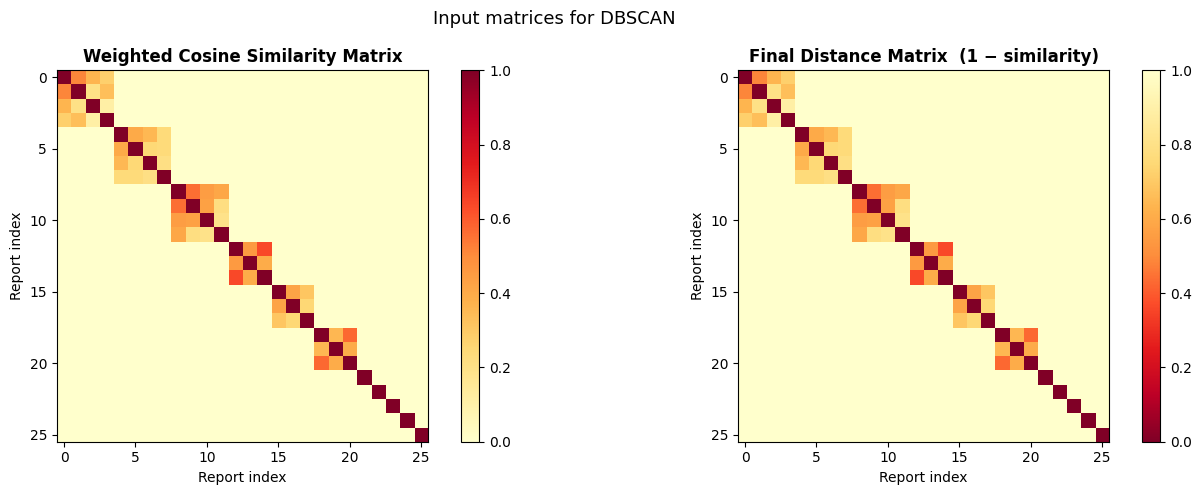

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(cos_sim, cmap="YlOrRd", vmin=0, vmax=1)
axes[0].set_title("Weighted Cosine Similarity Matrix", fontweight="bold")
axes[0].set_xlabel("Report index")
axes[0].set_ylabel("Report index")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(dist_matrix, cmap="YlOrRd_r", vmin=0, vmax=1)
axes[1].set_title("Final Distance Matrix  (1 − similarity)", fontweight="bold")
axes[1].set_xlabel("Report index")
axes[1].set_ylabel("Report index")
plt.colorbar(im1, ax=axes[1])

plt.suptitle("Input matrices for DBSCAN", fontsize=13)
plt.tight_layout()
plt.show()

## 7.  K-Distance (Elbow) Plot

**How to read this graph:**
- The x-axis is every data point, sorted by how far its k-th nearest neighbour is.
- Look for a sharp **"elbow"** (bend) in the curve.
- The distance at the elbow is your ideal **`DBSCAN_EPS`**.
- The red dashed line shows your **current** `DBSCAN_EPS = 0.85`.
  - If the elbow is **below** the red line → epsilon is too loose, lower it.
  - If the elbow is **above** the red line → epsilon is too tight, raise it.

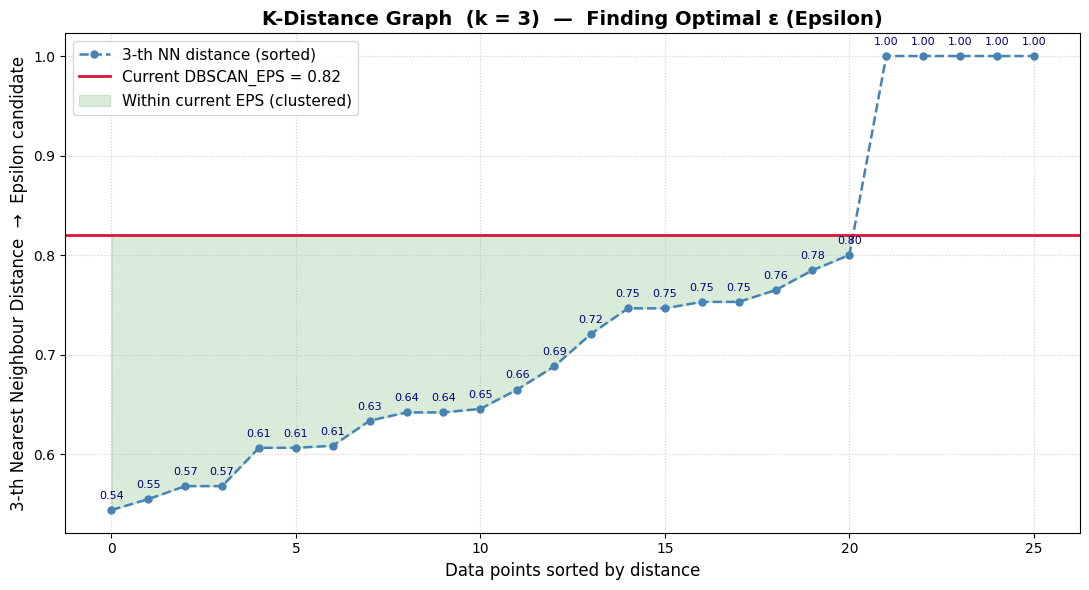


 K-Distance Summary
   k (MIN_SAMPLES)     : 3
   Min k-distance      : 0.5438
   Max k-distance      : 1.0000
   Median k-distance   : 0.7045
   Current DBSCAN_EPS  : 0.82
   Points within EPS   : 21/26 (80.8%)


In [12]:
def plot_k_distance(dist_matrix, k=DBSCAN_MIN_SAMPLES):
    """
    Plot the K-Distance graph to find the optimal DBSCAN epsilon.

    Parameters
    ----------
    dist_matrix : np.ndarray
        Precomputed distance matrix  (1.0 - cos_sim), shape (n, n).
    k : int
        Should match DBSCAN_MIN_SAMPLES (default 3).
    """
    if dist_matrix.shape[0] < k + 1:
        print(f" Not enough points ({dist_matrix.shape[0]}) for k={k}. Skipping plot.")
        return

   
    neigh = NearestNeighbors(n_neighbors=k, metric="precomputed")
    neigh.fit(dist_matrix)
    distances, indices = neigh.kneighbors(dist_matrix)

    #  Extract the k-th neighbour distance for every point 
   
    k_distances = np.sort(distances[:, k - 1])   
    fig, ax = plt.subplots(figsize=(11, 6))

    ax.plot(
        k_distances,
        marker="o", markersize=5,
        linestyle="--", linewidth=1.8,
        color="steelblue",
        label=f"{k}-th NN distance (sorted)",
    )

    # Current epsilon reference line
    ax.axhline(
        y=DBSCAN_EPS,
        color="crimson", linestyle="-", linewidth=2,
        label=f"Current DBSCAN_EPS = {DBSCAN_EPS}",
    )

    ax.fill_between(
        range(len(k_distances)), k_distances, DBSCAN_EPS,
        where=(k_distances <= DBSCAN_EPS),
        alpha=0.15, color="green",
        label="Within current EPS (clustered)",
    )

    ax.set_title(
        f"K-Distance Graph  (k = {k})  —  Finding Optimal ε (Epsilon)",
        fontsize=14, fontweight="bold",
    )
    ax.set_xlabel("Data points sorted by distance", fontsize=12)
    ax.set_ylabel(f"{k}-th Nearest Neighbour Distance  →  Epsilon candidate", fontsize=12)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(fontsize=11)

    for idx, val in enumerate(k_distances):
        ax.annotate(
            f"{val:.2f}",
            xy=(idx, val),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center", fontsize=8, color="navy",
        )

    plt.tight_layout()
    plt.show()
    print("\n K-Distance Summary")
    print(f"   k (MIN_SAMPLES)     : {k}")
    print(f"   Min k-distance      : {k_distances.min():.4f}")
    print(f"   Max k-distance      : {k_distances.max():.4f}")
    print(f"   Median k-distance   : {np.median(k_distances):.4f}")
    print(f"   Current DBSCAN_EPS  : {DBSCAN_EPS}")
    below = (k_distances <= DBSCAN_EPS).sum()
    print(f"   Points within EPS   : {below}/{len(k_distances)} ({100*below/len(k_distances):.1f}%)")

plot_k_distance(dist_matrix, k=DBSCAN_MIN_SAMPLES)

## 8. Run DBSCAN Clustering

In [13]:
labels = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES,
    metric="precomputed",
).fit_predict(dist_matrix)

print("DBSCAN labels:", labels)
unique_labels = set(labels)
n_clusters = len(unique_labels - {-1})
n_noise    = list(labels).count(-1)
print(f"\nClusters found : {n_clusters}")
print(f"Noise points   : {n_noise}")

# Silhouette Score
mask = labels != -1
if n_clusters > 1 and np.sum(mask) > 1:
    score = silhouette_score(
        dist_matrix[mask][:, mask],
        labels[mask],
        metric="precomputed",
    )
    print(f"\n--- CLUSTER QUALITY ---")
    print(f"Silhouette Score : {score:.4f}  (range -1 to 1, higher is better)")
    print(f"Total Clusters   : {n_clusters}")
    print(f"Noise Points     : {n_noise}")
else:
    print(f"\nSilhouette Score skipped — need > 1 cluster (got {n_clusters})")
# ──────────────────────────────────────────────────────────────────────────


DBSCAN labels: [ 0  0  0  0  1  1  1  1  2  2  2  2  3  3  3  4  4  4  5  5  5 -1 -1 -1
 -1 -1]

Clusters found : 6
Noise points   : 5

--- CLUSTER QUALITY ---
Silhouette Score : 0.3633  (range -1 to 1, higher is better)
Total Clusters   : 6
Noise Points     : 5


## 9. Summarise Each Cluster

In [ ]:
for cluster_label in sorted(set(labels)):
    if cluster_label == -1:
        idxs = [i for i, lbl in enumerate(labels) if lbl == -1]
        print(f"\n NOISE ({len(idxs)} points):")
        for i in idxs:
            print(f"   [{i}] {descriptions[i]}")
        continue

    idxs   = [i for i, lbl in enumerate(labels) if lbl == cluster_label]
    c_reps = [(lats[i], lons[i], descriptions[i], roles[i], categories[i]) for i in idxs]
    n_rep  = len(c_reps)

    c_lat  = sum(lats[i] for i in idxs) / len(idxs)
    c_lon  = sum(lons[i] for i in idxs) / len(idxs)

    dominant_cat = Counter(categories[i] for i in idxs).most_common(1)[0][0]
    n_guides     = sum(1 for i in idxs if roles[i] == "GUIDE")
    guide_ratio  = n_guides / n_rep
    confidence   = round(min(0.7, n_rep / 10) + guide_ratio * 0.3, 4)
    keywords     = _top_keywords(descriptions, idxs)
    severity     = _severity_from_confidence(confidence)

    print(f"\n Cluster {cluster_label}  ({n_rep} reports)")
    print(f"   Centroid       : ({c_lat:.4f}, {c_lon:.4f})")
    print(f"   Category       : {dominant_cat}")
    print(f"   Guide ratio    : {guide_ratio:.2f}  ({n_guides}/{n_rep} guides)")
    print(f"   Confidence     : {confidence}")
    print(f"   Severity       : {severity}")
    print(f"   Top keywords   : {keywords}")
    print("   Reports:")
    for i in idxs:
        print(f"      [{i}] {roles[i]:<8} | {descriptions[i]}")


 NOISE (5 points):
   [21] lost my hiking poles somewhere near lukla airport teahouse
   [22] yak sitting on the trail blocking path for a few minutes near dingboche not dangerous
   [23] small stream crossing is a bit slippery today near phakding be careful
   [24] saw a beautiful snow leopard on the ridge above camp once in a lifetime sighting
   [25] teahouse at pokhara lakeside running out of hot water showers not working

 Cluster 0  (4 reports)
   Centroid       : (27.9882, 86.9251)
   Category       : LANDSLIDE
   Guide ratio    : 0.50  (2/4 guides)
   Confidence     : 0.55
   Severity       : HIGH
   Top keywords   : ['landslide', 'camp', 'rocks', 'trail', 'completely']
   Reports:
      [0] GUIDE    | massive landslide blocking the main trail completely near base camp, huge boulders and mud
      [1] TOURIST  | large rocks and mud debris from landslide covering the trekking route to base camp
      [2] TOURIST  | trail completely destroyed by landslide, cannot pass at all, ro

## 10. Try Different Epsilon Values

Use the slider-style loop below to see how changing `eps` affects cluster count.

   EPS   Clusters   Noise
----------------------------
  0.30          0      26
  0.50          0      26
  0.65          5      10
  0.75          6       6
  0.85          6       5
  0.95          6       5


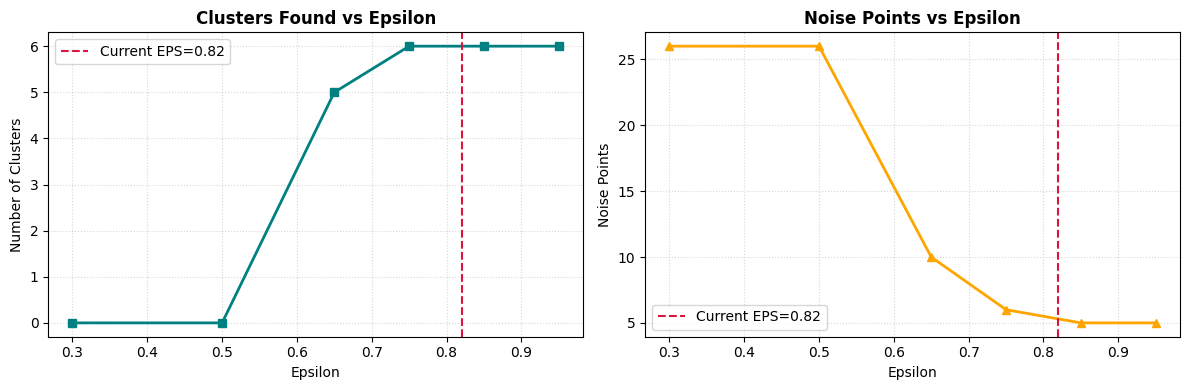

In [16]:
eps_values = [0.3, 0.5, 0.65, 0.75, 0.85, 0.95]

results = []
for eps in eps_values:
    lbl = DBSCAN(eps=eps, min_samples=DBSCAN_MIN_SAMPLES, metric="precomputed").fit_predict(dist_matrix)
    n_cl = len(set(lbl) - {-1})
    n_ns = list(lbl).count(-1)
    results.append((eps, n_cl, n_ns))

print(f"{'EPS':>6}  {'Clusters':>9}  {'Noise':>6}")
print("-" * 28)
for eps, n_cl, n_ns in results:
    marker = "  ← current" if eps == DBSCAN_EPS else ""
    print(f"{eps:>6.2f}  {n_cl:>9}  {n_ns:>6}{marker}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
eps_list   = [r[0] for r in results]
clust_list = [r[1] for r in results]
noise_list = [r[2] for r in results]

ax1.plot(eps_list, clust_list, marker="s", color="teal", linewidth=2)
ax1.axvline(x=DBSCAN_EPS, color="crimson", linestyle="--", label=f"Current EPS={DBSCAN_EPS}")
ax1.set_title("Clusters Found vs Epsilon", fontweight="bold")
ax1.set_xlabel("Epsilon")
ax1.set_ylabel("Number of Clusters")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.5)

ax2.plot(eps_list, noise_list, marker="^", color="orange", linewidth=2)
ax2.axvline(x=DBSCAN_EPS, color="crimson", linestyle="--", label=f"Current EPS={DBSCAN_EPS}")
ax2.set_title("Noise Points vs Epsilon", fontweight="bold")
ax2.set_xlabel("Epsilon")
ax2.set_ylabel("Noise Points")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

---
## Summary

| Step | What happened |
|------|---------------|
| Geo matrix | Haversine distance (km) between every pair of reports |
| Cosine matrix | TF-IDF weighted similarity with GUIDE boost |
| Geo masking | Zero-out pairs farther than `GEO_RADIUS_KM = 3.0 km` |
| dist_matrix | `1 - cosine_similarity` → used directly by DBSCAN |
| K-Distance plot | Finds the optimal `DBSCAN_EPS` visually |
| DBSCAN | Clusters reports into incidents + marks noise |

> **To integrate with Django:** after building `dist_matrix` inside `run_clustering()`,  
> call `plot_k_distance(dist_matrix, k=DBSCAN_MIN_SAMPLES, save_path="kdist.png")`.  
> The saved PNG can be served as a debug/admin diagnostic image.